In [279]:
import os
os.chdir('/workspaces/energy-prediction/')  # Change le répertoire vers la racine
print(os.getcwd())  # Vérif

/workspaces/energy-prediction


In [280]:
# Import des bibliothèques
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### Charger les données nettoyées

In [304]:
conso = pd.read_csv('./data/prepared/df_daily_conso.csv')
meteo = pd.read_csv('./data/prepared/meteo_clean.csv')
print(conso.columns)
print(meteo.columns)


Index(['Date', 'ConsommationGazTotale', 'ConsommationElectricite',
       'ConsommationTotale', 'month', 'day_of_week', 'is_weekend'],
      dtype='object')
Index(['date', 'temperature', 'humidity', 'pressure_sea_level',
       'wind_direction', 'wind_speed', 'min_soil_temp', 'latitude',
       'longitude', 'altitude', 'city_name', 'city_code', 'epci_name',
       'epci_code', 'department_name', 'department_code', 'region_name',
       'region_code', 'month_of_year'],
      dtype='object')


In [282]:
print(conso.head())
print(meteo.head())

                   DateHeure        Date  Heure  ConsommationGazGRTgaz  \
0  2024-04-30T21:00:00+00:00  30/04/2024  23:00                22574.0   
1  2024-04-30T20:00:00+00:00  30/04/2024  22:00                24265.0   
2  2024-04-30T19:00:00+00:00  30/04/2024  21:00                26171.0   
3  2024-04-30T18:00:00+00:00  30/04/2024  20:00                26980.0   
4  2024-04-30T17:00:00+00:00  30/04/2024  19:00                26876.0   

   ConsommationGazTerega  ConsommationGazTotale  ConsommationElectricite  \
0                 1562.0                24136.0                    46363   
1                 1758.0                26023.0                    46046   
2                 1966.0                28137.0                    46335   
3                 2064.0                29044.0                    47090   
4                 2010.0                28886.0                    48479   

   ConsommationTotale  
0             70499.0  
1             72069.0  
2             74472.0  
3 

##### conversion des dates

In [283]:
# Conversion des colonnes en format datetime
conso['Date'] = pd.to_datetime(conso['Date'], dayfirst=True)
conso['DateHeure'] = pd.to_datetime(conso['DateHeure'])
meteo['date'] = pd.to_datetime(meteo['date'])

In [284]:
# Vérification
print(conso[['Date', 'DateHeure']].head())
print(meteo['date'].head())

        Date                 DateHeure
0 2024-04-30 2024-04-30 21:00:00+00:00
1 2024-04-30 2024-04-30 20:00:00+00:00
2 2024-04-30 2024-04-30 19:00:00+00:00
3 2024-04-30 2024-04-30 18:00:00+00:00
4 2024-04-30 2024-04-30 17:00:00+00:00
0   2010-01-01 00:00:00+00:00
1   2010-01-01 03:00:00+00:00
2   2010-01-01 06:00:00+00:00
3   2010-01-01 09:00:00+00:00
4   2010-01-01 12:00:00+00:00
Name: date, dtype: datetime64[ns, UTC]


##### Fusion des fichiers sur la date

In [285]:
# Fusion des données sur DateHeure (conso) et date (meteo)
merged_data = pd.merge(conso, meteo, left_on='DateHeure', right_on='date', how='inner')

# Suppression de la colonne redondante `date` après la fusion
merged_data.drop(columns=['date'], inplace=True)

##### Verification de la fusion

In [286]:
# Vérification du résultat
#print(merged_data.head())
print(merged_data.columns)

Index(['DateHeure', 'Date', 'Heure', 'ConsommationGazGRTgaz',
       'ConsommationGazTerega', 'ConsommationGazTotale',
       'ConsommationElectricite', 'ConsommationTotale', 'temperature',
       'humidity', 'pressure_sea_level', 'wind_direction', 'wind_speed',
       'min_soil_temp', 'latitude', 'longitude', 'altitude', 'city_name',
       'city_code', 'epci_name', 'epci_code', 'department_name',
       'department_code', 'region_name', 'region_code', 'month_of_year'],
      dtype='object')


#### CORRELATION

In [287]:
print(merged_data.dtypes)

DateHeure                  datetime64[ns, UTC]
Date                            datetime64[ns]
Heure                                   object
ConsommationGazGRTgaz                  float64
ConsommationGazTerega                  float64
ConsommationGazTotale                  float64
ConsommationElectricite                  int64
ConsommationTotale                     float64
temperature                            float64
humidity                               float64
pressure_sea_level                     float64
wind_direction                         float64
wind_speed                             float64
min_soil_temp                          float64
latitude                               float64
longitude                              float64
altitude                                 int64
city_name                               object
city_code                               object
epci_name                               object
epci_code                              float64
department_na

##  Agréger les données à la journée

In [288]:
merged_data['Date'] = pd.to_datetime(merged_data['Date'])

sum_cols = ['ConsommationGazGRTgaz', 'ConsommationGazTerega',
            'ConsommationGazTotale', 'ConsommationElectricite', 'ConsommationTotale']

mean_cols = ['temperature', 'humidity', 'pressure_sea_level',
             'wind_direction', 'wind_speed', 'min_soil_temp']

df_daily = merged_data.groupby('Date')[sum_cols + mean_cols].agg({
    **{col: 'sum' for col in sum_cols},
    **{col: 'mean' for col in mean_cols}
}).reset_index()


### IMPORTS DES LIBS DU MODELE

In [289]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

###  Nettoyage des redondances

In [290]:
# Liste des colonnes redondantes à supprimer
cols_to_drop = [
    'ConsommationGazGRTgaz',  # sous-composant inutile
    'ConsommationGazTerega',  # idem
]
df_model = df_daily.drop(columns=cols_to_drop)



### Création des variables temporelles

In [291]:
df_model['month'] = df_model['Date'].dt.month
df_model['day_of_week'] = df_model['Date'].dt.dayofweek
df_model['is_weekend'] = df_model['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)


### FEATURE & TARGET

In [292]:
target = 'ConsommationTotale'
features = [col for col in df_model.columns if col not in ['Date', target]]

X = df_model[features]
y = df_model[target]


### STANDARDISATION

In [293]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### SPLIT TRAIN/TEST

In [294]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


###  Ridge Regression

In [295]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

Ridge()

### Évaluation

In [296]:
y_pred = ridge.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"📈 RMSE: {rmse:.2f}")
print(f"📉 MAE : {mae:.2f}")


📈 RMSE: 203.47
📉 MAE : 151.80


### Importance des variables

In [297]:
coeffs = pd.Series(ridge.coef_, index=features)
coeffs_abs = coeffs.abs().sort_values(ascending=False)

print("🔍 Top variables influentes :")
print(coeffs_abs)


🔍 Top variables influentes :
ConsommationGazTotale      219974.944206
ConsommationElectricite     86755.481325
temperature                   428.885462
is_weekend                     54.903461
humidity                       51.902790
min_soil_temp                  49.298792
month                          47.068239
wind_direction                 35.437033
day_of_week                     6.217992
pressure_sea_level              3.772084
wind_speed                      3.326744
dtype: float64


### Visualisation

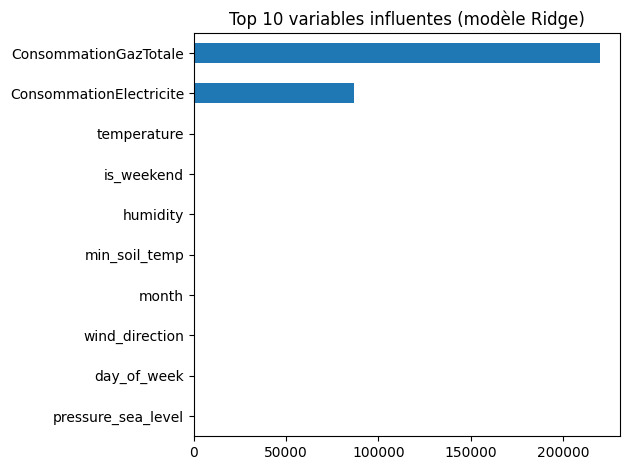

In [298]:
import matplotlib.pyplot as plt

coeffs_abs.head(10).plot(kind='barh')
plt.title("Top 10 variables influentes (modèle Ridge)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [299]:
# Comparaison y_test vs y_pred
df_resultats = pd.DataFrame({
    'Réel': y_test.values,
    'Prédit': y_pred
})
print(df_resultats.head(10))


        Réel        Prédit
0   541692.0  5.421264e+05
1  1204549.0  1.204670e+06
2   979764.0  9.799963e+05
3   969921.0  9.699017e+05
4   804540.0  8.045869e+05
5   978983.0  9.788355e+05
6  1056840.0  1.056913e+06
7   613851.0  6.139476e+05
8   594415.0  5.942623e+05
9   961834.0  9.619045e+05


In [300]:
def predict_conso_for_date(date_str, df_model, model, scaler):
    """
    Prédit la consommation totale pour une date donnée à partir des données existantes dans df_model.

    Params :
        - date_str : string 'YYYY-MM-DD'
        - df_model : DataFrame contenant la colonne 'Date' + toutes les features
        - model : modèle Ridge déjà entraîné
        - scaler : StandardScaler déjà entraîné

    Retour :
        - Affiche la prédiction ou un message d'erreur
    """
    import pandas as pd

    date = pd.to_datetime(date_str)

    # Chercher la ligne correspondante
    row = df_model[df_model['Date'] == date]

    if row.empty:
        print(f"❌ Aucune donnée disponible pour la date : {date_str}")
        return None

    # Définir les colonnes features
    target = 'ConsommationTotale'
    features = [col for col in df_model.columns if col not in ['Date', target]]

    X_input = row[features]

    # Standardisation
    X_scaled = scaler.transform(X_input)

    # Prédiction
    prediction = model.predict(X_scaled)[0]

    print(f"🔮 Consommation prédite pour le {date_str} : {prediction:.0f} MWh")
    return prediction


In [301]:
# 💡 Remplace ici par la date que tu veux tester
ma_date = "2024-04-30"


In [302]:
# Lancer la prédiction avec ta date
predict_conso_for_date(ma_date, df_model, ridge, scaler)


🔮 Consommation prédite pour le 2024-04-30 : 615022 MWh


np.float64(615021.544744656)